# A dynamic task assignment model (TTAP) - Exact Method

### Fecha: 21 de Junio de 2026

Versión Inicial V.01
MILP de rutas sobre una red de estados alcanzables



Construyendo red de estados...

H1: 8,483 estados | 45,118 arcos
H2: 492 estados | 1,343 arcos
H3: 8,070 estados | 42,544 arcos
H4: 828 estados | 2,309 arcos

Total arcos/variables binarias: 91,314

Resolviendo MILP...

Variables binarias : 91,314
Restricciones      : 17,893
No ceros matriz A  : 240,020
Time limit         : 180 segundos
MIP relative gap   : 1e-06
Running HiGHS 1.2.2 [date: 2023-05-05, git hash: n/a]
Copyright (c) 2022 ERGO-Code under MIT licence terms

Estado del solver:
Optimization terminated successfully. (HiGHS Status 7: Optimal)
Tiempo total: 13.18 segundos

Beneficio exacto v0.1: 0.464492
Óptimo certificado por el solver.

Comparación inicial contra greedy reportado:
Greedy reportado : 0.440000
Exacto v0.1      : 0.464492
Diferencia       : 0.024492
Presolving model
17730 rows, 91151 cols, 239694 nonzeros
12483 rows, 75401 cols, 214886 nonzeros

Solving MIP model with:
   12483 rows
   75401 cols (75401 binary, 0 integer, 0 implied int., 0 continuous)
   214886 

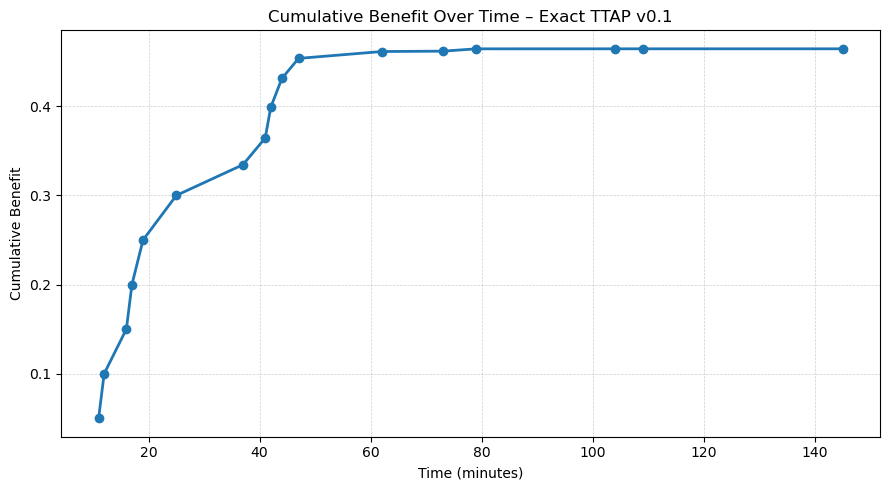

In [3]:
# ============================================================
# TTAP Exacto v0.1
# Modelo MILP sobre red de estados alcanzables
# Misma lógica operacional que el Greedy TTAP:
# - beneficio temporal sigmoidal normalizado
# - tiempos de vuelo por helicóptero
# - servicio fijo de 6 minutos
# - retorno a base + recuperación de 2 minutos
# - capacidades consumibles y recarga en base
# ============================================================

import math
import time
from collections import deque, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import coo_matrix


# ============================================================
# 1. PARÁMETROS GENERALES
# ============================================================

SERVICE_TIME = 6.0
RECOVERY_TIME = 2.0
TMAX = 300.0
ALPHA = 0.1

# Grilla temporal:
# 1.0 = modelo por minutos, más rápido.
# 0.5 = más fino.
# 0.1 = más cercano al greedy continuo, pero más grande.
TIME_UNIT = 1.0

GREEDY_REPORTED_BENEFIT = 0.440
GREEDY_REPORTED_TASKS = 17


# ============================================================
# 2. DATOS DEL ESCENARIO
# ============================================================

nodes = {
    "Base": (0.0, 0.0),
    "A": (10.0, 5.0),
    "B": (20.0, 15.0),
    "C": (30.0, 10.0),
    "D": (40.0, 20.0),
}

# Formato:
# task_id, visual_search_required, load, med, pers, t_opt, t_eff, t_ineff
task_rows = [
    (1,  True,  200, 2, 1, 20, 40, 60),
    (2,  False, 300, 1, 2, 15, 30, 50),
    (3,  True,  100, 3, 0, 10, 25, 40),
    (4,  False, 200, 0, 3, 30, 50, 70),
    (5,  True,  150, 1, 1, 25, 45, 60),
    (6,  True,  100, 3, 0, 10, 25, 120),
    (7,  False, 400, 0, 3, 30, 50, 90),
    (8,  True,  150, 1, 1, 25, 45, 100),
    (9,  True,  200, 2, 1, 20, 40, 60),
    (10, False, 300, 1, 2, 15, 30, 50),
    (11, True,  100, 3, 0, 10, 25, 40),
    (12, False, 200, 0, 3, 30, 50, 70),
    (13, True,  150, 1, 1, 25, 45, 60),
    (14, True,  100, 3, 0, 10, 25, 120),
    (15, False, 400, 0, 3, 30, 50, 90),
    (16, True,  150, 1, 1, 25, 45, 100),
    (17, True,  150, 1, 1, 25, 45, 60),
    (18, True,  100, 3, 0, 10, 25, 120),
    (19, False, 400, 0, 3, 30, 50, 90),
    (20, True,  150, 1, 1, 25, 45, 100),
]

tasks = {
    row[0]: {
        "visual": row[1],
        "load": row[2],
        "med": row[3],
        "pers": row[4],
        "t_opt": row[5],
        "t_eff": row[6],
        "t_ineff": row[7],
    }
    for row in task_rows
}

task_to_node = {}

for i in [1, 2, 9, 10]:
    task_to_node[i] = "A"

for i in [3, 8, 7, 11, 12, 13, 14]:
    task_to_node[i] = "B"

for i in [5, 6, 15, 16]:
    task_to_node[i] = "C"

for i in [4, 17, 18, 19, 20]:
    task_to_node[i] = "D"


# Helicópteros según comportamiento del greedy:
# H1 y H3 pueden hacer tareas de búsqueda visual.
# H2 y H4 no pueden hacer tareas de búsqueda visual.
helicopters = {
    "H1": {"visual": True,  "load": 500, "med": 3, "pers": 3, "speed": 150},
    "H2": {"visual": False, "load": 500, "med": 3, "pers": 3, "speed": 120},
    "H3": {"visual": True,  "load": 500, "med": 3, "pers": 3, "speed": 140},
    "H4": {"visual": False, "load": 500, "med": 3, "pers": 3, "speed": 160},
}


# ============================================================
# 3. FUNCIONES OPERACIONALES
# ============================================================

def euclidean_distance(node_a, node_b):
    xa, ya = nodes[node_a]
    xb, yb = nodes[node_b]
    return math.hypot(xa - xb, ya - yb)


def travel_time_minutes(h, node_a, node_b):
    """
    Tiempo de vuelo en minutos:
    tau = 60 * distancia / velocidad
    """
    if node_a == node_b:
        return 0.0

    speed = helicopters[h]["speed"]
    distance = euclidean_distance(node_a, node_b)

    return 60.0 * distance / speed


def ceil_steps(minutes, time_unit):
    """
    Convierte una duración continua a pasos discretos.
    Usamos techo para no permitir tiempos físicamente más rápidos
    que el cálculo continuo.
    """
    return int(math.ceil((minutes - 1e-9) / time_unit))


def time_from_step(k, time_unit):
    return k * time_unit


def satisfaction(t, task):
    """
    Misma lógica de beneficio temporal del greedy:
    - 1 si llega antes o en tiempo óptimo
    - 0 si llega después o en tiempo ineficiente
    - sigmoide decreciente entre ambos
    """
    if t <= task["t_opt"]:
        return 1.0

    if t >= task["t_ineff"]:
        return 0.0

    return 1.0 / (1.0 + math.exp(ALPHA * (t - task["t_eff"])))


def task_benefit(task_id, finish_time):
    """
    Beneficio normalizado:
    b_i(t) = S_i(t) / número total de tareas
    """
    return satisfaction(finish_time, tasks[task_id]) / len(tasks)


def can_execute_task(h, task_id, load, med, pers):
    """
    Compatibilidad entre helicóptero y tarea.
    """
    helo = helicopters[h]
    task = tasks[task_id]

    if task["visual"] and not helo["visual"]:
        return False

    if load < task["load"]:
        return False

    if med < task["med"]:
        return False

    if pers < task["pers"]:
        return False

    return True


def make_state(node, k, load, med, pers):
    """
    Estado discreto.
    k es índice temporal, no tiempo directamente.
    """
    return (node, int(k), int(load), int(med), int(pers))


def start_state(h):
    return make_state(
        "Base",
        0,
        helicopters[h]["load"],
        helicopters[h]["med"],
        helicopters[h]["pers"],
    )


def sink_state():
    return ("SINK", -1, 0, 0, 0)


# ============================================================
# 4. CONSTRUCCIÓN DE LA RED DE ESTADOS PARA CADA HELICÓPTERO
# ============================================================

def build_state_graph_for_helicopter(h, time_unit=TIME_UNIT):
    """
    Construye una red de estados alcanzables para un helicóptero.

    Cada arco puede ser:
    - "task": ejecutar tarea
    - "return": volver a base y recuperar
    - "end": terminar la ruta

    No usamos variables q ni Big-M.
    Los recursos quedan incorporados directamente en el estado.
    """

    tmax_steps = int(round(TMAX / time_unit))

    s0 = start_state(h)
    sink = sink_state()

    states = set()
    states.add(s0)

    queue = deque([s0])
    arcs = []

    while queue:
        current_state = queue.popleft()

        node, k, load, med, pers = current_state
        current_time = time_from_step(k, time_unit)

        # ----------------------------------------------------
        # 4.1 Arcos de tarea
        # ----------------------------------------------------
        for task_id in tasks:

            if not can_execute_task(h, task_id, load, med, pers):
                continue

            task_node = task_to_node[task_id]

            flight = travel_time_minutes(h, node, task_node)
            duration = flight + SERVICE_TIME
            duration_steps = ceil_steps(duration, time_unit)

            k_new = k + duration_steps

            if k_new > tmax_steps:
                continue

            finish_time = time_from_step(k_new, time_unit)

            task = tasks[task_id]

            new_state = make_state(
                task_node,
                k_new,
                load - task["load"],
                med - task["med"],
                pers - task["pers"],
            )

            benefit = task_benefit(task_id, finish_time)

            arcs.append({
                "h": h,
                "from": current_state,
                "to": new_state,
                "kind": "task",
                "task": task_id,
                "start_time": current_time,
                "finish_time": finish_time,
                "flight_time": flight,
                "service_time": SERVICE_TIME,
                "benefit": benefit,
            })

            if new_state not in states:
                states.add(new_state)
                queue.append(new_state)

        # ----------------------------------------------------
        # 4.2 Arco de retorno a base + recuperación
        # ----------------------------------------------------
        if node != "Base":

            flight = travel_time_minutes(h, node, "Base")
            duration = flight + RECOVERY_TIME
            duration_steps = ceil_steps(duration, time_unit)

            k_new = k + duration_steps

            if k_new <= tmax_steps:

                new_state = make_state(
                    "Base",
                    k_new,
                    helicopters[h]["load"],
                    helicopters[h]["med"],
                    helicopters[h]["pers"],
                )

                arcs.append({
                    "h": h,
                    "from": current_state,
                    "to": new_state,
                    "kind": "return",
                    "task": None,
                    "start_time": current_time,
                    "finish_time": time_from_step(k_new, time_unit),
                    "flight_time": flight,
                    "service_time": RECOVERY_TIME,
                    "benefit": 0.0,
                })

                if new_state not in states:
                    states.add(new_state)
                    queue.append(new_state)

    # --------------------------------------------------------
    # 4.3 Arcos de término
    # --------------------------------------------------------
    states.add(sink)

    for s in list(states):
        if s == sink:
            continue

        node, k, load, med, pers = s

        arcs.append({
            "h": h,
            "from": s,
            "to": sink,
            "kind": "end",
            "task": None,
            "start_time": time_from_step(k, time_unit),
            "finish_time": time_from_step(k, time_unit),
            "flight_time": 0.0,
            "service_time": 0.0,
            "benefit": 0.0,
        })

    return list(states), arcs


def build_full_graph(time_unit=TIME_UNIT):
    states_by_h = {}
    arcs_by_h = {}
    all_arcs = []

    print("\nConstruyendo red de estados...\n")

    for h in helicopters:
        states, arcs = build_state_graph_for_helicopter(h, time_unit)

        states_by_h[h] = states
        arcs_by_h[h] = arcs
        all_arcs.extend(arcs)

        print(f"{h}: {len(states):,} estados | {len(arcs):,} arcos")

    print(f"\nTotal arcos/variables binarias: {len(all_arcs):,}")

    return states_by_h, arcs_by_h, all_arcs


# ============================================================
# 5. CONSTRUCCIÓN DEL MILP
# ============================================================

def build_milp_matrices(states_by_h, arcs_by_h, all_arcs):
    """
    Construye:
    - vector objetivo c
    - matriz de restricciones A
    - cotas inferiores y superiores
    - integrality
    """

    n_vars = len(all_arcs)

    # SciPy milp minimiza, por eso usamos -benefit.
    c = np.array([-arc["benefit"] for arc in all_arcs], dtype=float)

    lb = np.zeros(n_vars)
    ub = np.ones(n_vars)
    integrality = np.ones(n_vars, dtype=int)

    row_idx = []
    col_idx = []
    vals = []

    rhs_lb = []
    rhs_ub = []

    current_row = 0

    # Mapa de índices globales
    arc_global_index = {}
    offset = 0

    for h in helicopters:
        for local_idx, arc in enumerate(arcs_by_h[h]):
            arc_global_index[(h, local_idx)] = offset + local_idx
        offset += len(arcs_by_h[h])

    # --------------------------------------------------------
    # 5.1 Conservación de flujo por helicóptero
    # --------------------------------------------------------
    for h in helicopters:

        outgoing = defaultdict(list)
        incoming = defaultdict(list)

        for local_idx, arc in enumerate(arcs_by_h[h]):
            j = arc_global_index[(h, local_idx)]

            outgoing[arc["from"]].append(j)
            incoming[arc["to"]].append(j)

        s0 = start_state(h)
        sink = sink_state()

        for state in states_by_h[h]:

            # + salidas
            for j in outgoing.get(state, []):
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(1.0)

            # - entradas
            for j in incoming.get(state, []):
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(-1.0)

            if state == s0:
                rhs = 1.0
            elif state == sink:
                rhs = -1.0
            else:
                rhs = 0.0

            rhs_lb.append(rhs)
            rhs_ub.append(rhs)

            current_row += 1

    # --------------------------------------------------------
    # 5.2 Cada tarea máximo una vez
    # --------------------------------------------------------
    for task_id in tasks:

        for j, arc in enumerate(all_arcs):
            if arc["kind"] == "task" and arc["task"] == task_id:
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(1.0)

        rhs_lb.append(-np.inf)
        rhs_ub.append(1.0)

        current_row += 1

    A = coo_matrix(
        (vals, (row_idx, col_idx)),
        shape=(current_row, n_vars)
    ).tocsr()

    constraints = LinearConstraint(
        A,
        np.array(rhs_lb, dtype=float),
        np.array(rhs_ub, dtype=float)
    )

    bounds = Bounds(lb, ub)

    return c, integrality, bounds, constraints


# ============================================================
# 6. RESOLUCIÓN
# ============================================================

def solve_exact_ttap_v01(time_unit=TIME_UNIT, time_limit=180, mip_rel_gap=1e-6):
    """
    Resuelve la versión exacta v0.1.

    Importante:
    Si el solver termina por límite de tiempo, la solución encontrada
    puede ser factible, pero no óptima certificada.
    """

    t0 = time.time()

    states_by_h, arcs_by_h, all_arcs = build_full_graph(time_unit)

    c, integrality, bounds, constraints = build_milp_matrices(
        states_by_h,
        arcs_by_h,
        all_arcs
    )

    print("\nResolviendo MILP...\n")
    print(f"Variables binarias : {len(all_arcs):,}")
    print(f"Restricciones      : {constraints.A.shape[0]:,}")
    print(f"No ceros matriz A  : {constraints.A.nnz:,}")
    print(f"Time limit         : {time_limit} segundos")
    print(f"MIP relative gap   : {mip_rel_gap}")

    result = milp(
        c=c,
        integrality=integrality,
        bounds=bounds,
        constraints=constraints,
        options={
            "time_limit": time_limit,
            "mip_rel_gap": mip_rel_gap,
            "disp": True,
        }
    )

    runtime = time.time() - t0

    print("\nEstado del solver:")
    print(result.message)
    print(f"Tiempo total: {runtime:.2f} segundos")

    if result.x is None:
        raise RuntimeError("El solver no encontró solución factible.")

    objective_value = -result.fun

    print(f"\nBeneficio exacto v0.1: {objective_value:.6f}")

    if result.success:
        print("Óptimo certificado por el solver.")
    else:
        print("Advertencia: no hay optimalidad certificada. Puede ser solución incumbente.")

    print("\nComparación inicial contra greedy reportado:")
    print(f"Greedy reportado : {GREEDY_REPORTED_BENEFIT:.6f}")
    print(f"Exacto v0.1      : {objective_value:.6f}")
    print(f"Diferencia       : {objective_value - GREEDY_REPORTED_BENEFIT:.6f}")

    return result, all_arcs, states_by_h, arcs_by_h, runtime


# ============================================================
# 7. DECODIFICACIÓN DE LA SOLUCIÓN
# ============================================================

def decode_solution(result, all_arcs, time_unit=TIME_UNIT):
    """
    Reconstruye las rutas seleccionadas por helicóptero.
    """

    selected_indices = [
        j for j, value in enumerate(result.x)
        if value > 0.5
    ]

    selected_arcs = [all_arcs[j] for j in selected_indices]

    selected_by_h = defaultdict(list)

    for arc in selected_arcs:
        selected_by_h[arc["h"]].append(arc)

    rows = []

    for h in helicopters:

        # Mapa from_state -> arc seleccionado
        out_arc = {
            arc["from"]: arc
            for arc in selected_by_h[h]
        }

        current = start_state(h)

        while True:

            arc = out_arc.get(current)

            if arc is None:
                break

            if arc["kind"] == "end":
                break

            if arc["kind"] == "task":

                task_id = arc["task"]
                next_state = arc["to"]

                rows.append({
                    "Helo ID": h,
                    "Task ID": task_id,
                    "Status": "Task Executed",
                    "From": arc["from"][0],
                    "Node": task_to_node[task_id],
                    "Start Time": arc["start_time"],
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Completion Time": arc["finish_time"],
                    "Benefit": arc["benefit"],
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                })

            elif arc["kind"] == "return":

                next_state = arc["to"]

                rows.append({
                    "Helo ID": h,
                    "Task ID": "Base",
                    "Status": "Return + Recovery",
                    "From": arc["from"][0],
                    "Node": "Base",
                    "Start Time": arc["start_time"],
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Completion Time": arc["finish_time"],
                    "Benefit": 0.0,
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                })

            current = arc["to"]

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values(
            by=["Start Time", "Completion Time", "Helo ID"]
        ).reset_index(drop=True)

    return df


def print_solution_report(df):
    """
    Reporte comparable con el greedy.
    """

    if df.empty:
        print("No hay actividades seleccionadas.")
        return

    task_df = df[df["Status"] == "Task Executed"].copy()

    total_benefit = task_df["Benefit"].sum()
    completed_tasks = task_df["Task ID"].nunique()

    print("\nResumen cronológico:\n")

    for _, row in df.iterrows():
        if row["Status"] == "Task Executed":
            print(
                f"{row['Helo ID']} → T{row['Task ID']} "
                f"fin={row['Completion Time']:.1f}' "
                f"ΔB={row['Benefit']:.6f}"
            )
        else:
            print(
                f"{row['Helo ID']} → Base to recover "
                f"fin={row['Completion Time']:.1f}'"
            )

    print("\nMétricas globales:")
    print(f"► Tareas completadas : {completed_tasks}/{len(tasks)}")
    print(f"► Beneficio total    : {total_benefit:.6f}")
    print(f"► Greedy reportado   : {GREEDY_REPORTED_BENEFIT:.6f}")
    print(f"► Diferencia         : {total_benefit - GREEDY_REPORTED_BENEFIT:.6f}")

    uncompleted = sorted(set(tasks.keys()) - set(task_df["Task ID"]))

    print(f"► Tareas no completadas: {uncompleted}")

    print("\nCapacity Usage Log:\n")
    print(df.to_string(index=False))


# ============================================================
# 8. GRÁFICO DE BENEFICIO ACUMULADO
# ============================================================

def plot_cumulative_benefit(df):
    task_df = df[df["Status"] == "Task Executed"].copy()

    if task_df.empty:
        print("No hay tareas ejecutadas para graficar.")
        return

    task_df = task_df.sort_values("Completion Time")
    task_df["Cumulative Benefit"] = task_df["Benefit"].cumsum()

    plt.figure(figsize=(9, 5))
    plt.plot(
        task_df["Completion Time"],
        task_df["Cumulative Benefit"],
        marker="o",
        linewidth=2,
    )
    plt.xlabel("Time (minutes)")
    plt.ylabel("Cumulative Benefit")
    plt.title("Cumulative Benefit Over Time – Exact TTAP v0.1")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.tight_layout()
    plt.show()


# ============================================================
# 9. EJECUCIÓN PRINCIPAL
# ============================================================

if __name__ == "__main__":

    result, all_arcs, states_by_h, arcs_by_h, runtime = solve_exact_ttap_v01(
        time_unit=TIME_UNIT,
        time_limit=180,
        mip_rel_gap=1e-6,
    )

    df_solution = decode_solution(
        result,
        all_arcs,
        time_unit=TIME_UNIT
    )

    print_solution_report(df_solution)

    plot_cumulative_benefit(df_solution)

## Carta Gantt

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np


def helo_to_int(helo_id):
    """
    Convierte Helo ID a entero:
    1    -> 1
    '1'  -> 1
    'H1' -> 1
    """
    if isinstance(helo_id, str):
        helo_id = helo_id.strip()
        if helo_id.startswith("H"):
            return int(helo_id.replace("H", ""))
        return int(helo_id)
    return int(helo_id)


def normalize_status(status):
    """
    Homologa nombres de estado entre Greedy y Exacto.
    """
    status = str(status)

    if status in ["Task Executed", "Executed"]:
        return "Task Executed"

    if status in ["Idle", "Return + Recovery", "Return", "Base"]:
        return "Return + Recovery"

    return status


def plot_ttap_gantt_like_greedy(
    df,
    title="Gantt Chart – TTAP",
    fixed_service_time=6,
    show_benefit=False,
    xlim=None,
    save_path=None
):
    """
    Gráfico Gantt estilo Greedy TTAP.

    Funciona con:
    - df_capacity del greedy
    - df_solution del exacto v0.1

    Columnas esperadas:
    - Helo ID
    - Task ID
    - Status
    - Flight Time
    - Service Time
    - Completion Time

    Columnas opcionales:
    - Benefit
    """

    # --------------------------------------------------------
    # 1. Preparar datos
    # --------------------------------------------------------
    records = []
    prev_finish = {}

    df_plot = df.copy()

    df_plot["Helo ID"] = df_plot["Helo ID"].apply(helo_to_int)
    df_plot["Status"] = df_plot["Status"].apply(normalize_status)

    df_plot["Flight Time"] = df_plot["Flight Time"].astype(float)
    df_plot["Service Time"] = df_plot["Service Time"].astype(float)
    df_plot["Completion Time"] = df_plot["Completion Time"].astype(float)

    # Ordenar cronológicamente para reconstruir bien cada línea de helicóptero
    df_plot = df_plot.sort_values(
        by=["Completion Time", "Helo ID"]
    ).reset_index(drop=True)

    for _, row in df_plot.iterrows():

        heli = int(row["Helo ID"])
        task = row["Task ID"]
        finish = float(row["Completion Time"])
        service_time = float(row["Service Time"])
        flight_time = float(row["Flight Time"])
        status = row["Status"]

        # Mismo criterio visual del gráfico greedy:
        # el inicio de cada bloque del helicóptero es el término de su actividad previa.
        start = prev_finish.get(heli, 0.0)

        travel = flight_time
        actual_service = service_time

        prev_finish[heli] = finish

        benefit = None
        if "Benefit" in df_plot.columns and pd.notna(row.get("Benefit", np.nan)):
            benefit = float(row["Benefit"])

        records.append({
            "heli": heli,
            "task": task,
            "start": start,
            "travel": travel,
            "service": actual_service,
            "finish": finish,
            "status": status,
            "benefit": benefit,
        })

    if not records:
        print("No hay registros para graficar.")
        return

    # --------------------------------------------------------
    # 2. Graficar
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(18, 5))

    colors = {
        "travel": "#9ecae1",
        "service": "#3182bd",
        "idle": "#cccccc",
    }

    for rec in records:

        y = rec["heli"]

        # -----------------------------
        # Vuelo
        # -----------------------------
        if rec["travel"] > 0:
            ax.broken_barh(
                [(rec["start"], rec["travel"])],
                (y - 0.35, 0.3),
                facecolors=colors["travel"]
            )

        # -----------------------------
        # Servicio o recuperación
        # -----------------------------
        service_start = rec["start"] + rec["travel"]

        if rec["status"] == "Task Executed":
            service_color = colors["service"]
        else:
            service_color = colors["idle"]

        ax.broken_barh(
            [(service_start, rec["service"])],
            (y - 0.35, 0.3),
            facecolors=service_color
        )

        # -----------------------------
        # Etiqueta
        # -----------------------------
        if rec["status"] == "Task Executed":

            if show_benefit and rec["benefit"] is not None:
                label = f"T{rec['task']}\n{rec['benefit']:.3f}"
            else:
                label = f"T{rec['task']}"

            text_color = "white"

        else:
            label = "Base"
            text_color = "black"

        ax.text(
            service_start + rec["service"] / 2,
            y - 0.35 + 0.15,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=8
        )

    # --------------------------------------------------------
    # 3. Formato
    # --------------------------------------------------------
    helos = sorted(set(r["heli"] for r in records))

    ax.set_xlabel("Time (minutes)")
    ax.set_yticks(helos)
    ax.set_yticklabels([f"H{i}" for i in helos])
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.4)
    ax.set_ylim(0.2, max(helos) + 0.8)

    if xlim is not None:
        ax.set_xlim(xlim)

    patches = [
        mpatches.Patch(color=colors["travel"], label="Flight Time"),
        mpatches.Patch(color=colors["service"], label=f"Service Time ({fixed_service_time} min)"),
        mpatches.Patch(color=colors["idle"], label="Recovery/IDLE Time (2 min)")
    ]

    ax.legend(handles=patches, loc="upper right")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

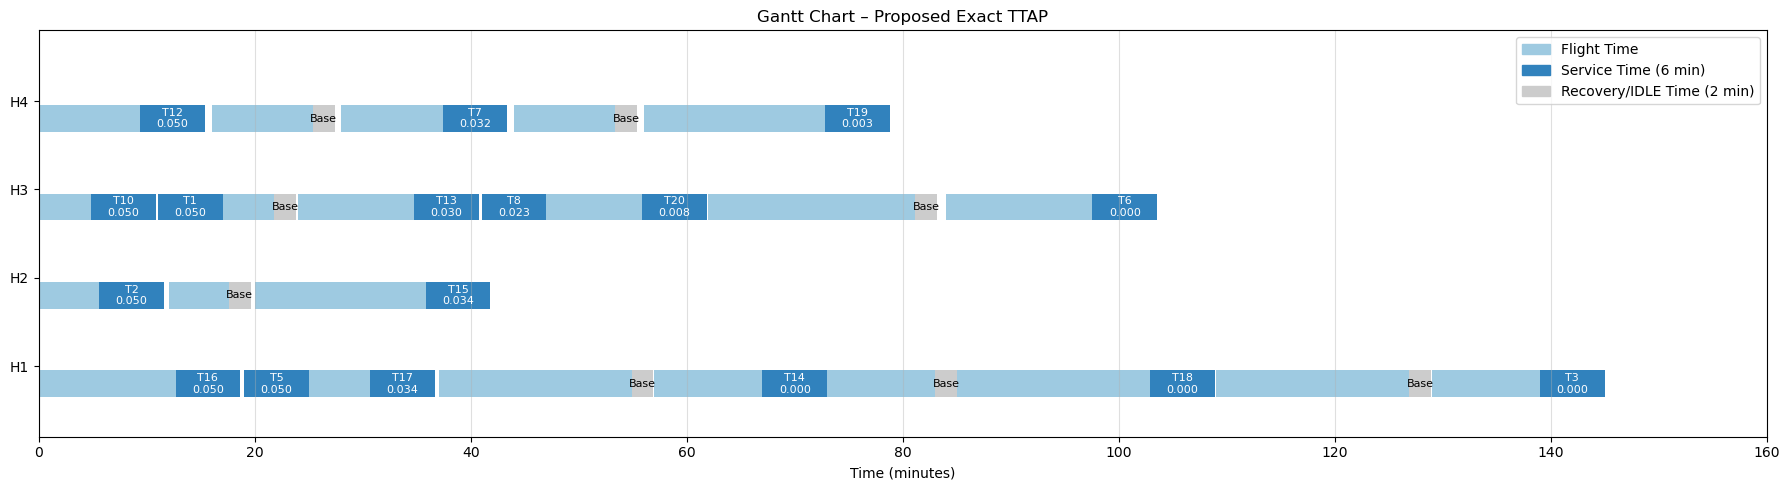

In [7]:
plot_ttap_gantt_like_greedy(
    df_solution,
    title="Gantt Chart – Proposed Exact TTAP",
    show_benefit=True,
    xlim=(0, 160),
    save_path="gantt_exact_ttap.png"
)